# 1. Import Libraries

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
import joblib
import warnings
warnings.filterwarnings("ignore")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


# 2. Data Loading and Initial Exploration

In [2]:
# Load the dataset
df = pd.read_csv('telco_churn.csv')
print("✓ Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Number of records: {df.shape[0]}")

✓ Dataset loaded successfully!

Dataset shape: (7395, 21)
Number of records: 7395


In [3]:
# Display all column names
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Display last few rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7390,5275-SQEIZ,Male,0,No,No,1.0,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Mailed check,80.85,NaN,Yes
7391,3282-ZISZV,Male,0,No,Yes,32.0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),83.70,2633.3,No
7392,7890-VYYWG,Male,1,Yes,No,3.0,No,No phone service,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Mailed check,NaN,93.7,Yes
7393,4061-UKJWL,Male,0,No,No,3.0,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,45.45,141.7,No
7394,5063-IUOKK,Male,0,No,No,13.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,NaN,265.75,No


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7395 entries, 0 to 7394
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7395 non-null   object 
 1   gender            7395 non-null   object 
 2   SeniorCitizen     7395 non-null   int64  
 3   Partner           7395 non-null   object 
 4   Dependents        7395 non-null   object 
 5   tenure            7322 non-null   float64
 6   PhoneService      7395 non-null   object 
 7   MultipleLines     7395 non-null   object 
 8   InternetService   7395 non-null   object 
 9   OnlineSecurity    7395 non-null   object 
 10  OnlineBackup      7395 non-null   object 
 11  DeviceProtection  7395 non-null   object 
 12  TechSupport       7395 non-null   object 
 13  StreamingTV       7395 non-null   object 
 14  StreamingMovies   7395 non-null   object 
 15  Contract          7324 non-null   object 
 16  PaperlessBilling  7395 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7395 entries, 0 to 7394
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7395 non-null   object 
 1   gender            7395 non-null   object 
 2   SeniorCitizen     7395 non-null   int64  
 3   Partner           7395 non-null   object 
 4   Dependents        7395 non-null   object 
 5   tenure            7322 non-null   float64
 6   PhoneService      7395 non-null   object 
 7   MultipleLines     7395 non-null   object 
 8   InternetService   7395 non-null   object 
 9   OnlineSecurity    7395 non-null   object 
 10  OnlineBackup      7395 non-null   object 
 11  DeviceProtection  7395 non-null   object 
 12  TechSupport       7395 non-null   object 
 13  StreamingTV       7395 non-null   object 
 14  StreamingMovies   7395 non-null   object 
 15  Contract          7324 non-null   object 
 16  PaperlessBilling  7395 non-null   object 


In [8]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7395.000000,7322.000000,7311.000000,7304.000000
mean,0.161325,32.508741,64.784961,2294.600767
std,0.367856,24.593340,30.121344,2273.873998
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.787500
50%,0.000000,29.000000,70.400000,1410.250000
75%,0.000000,56.000000,89.875000,3822.887500
max,1.000000,72.000000,118.750000,8684.800000


# 3. Data Preprocessing - Missing Values & Duplicates

### 3.1 Check Missing Values

In [9]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
print(missing_df)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values Summary:
                Missing_Count  Missing_Percentage
TotalCharges               91            1.230561
MonthlyCharges             84            1.135903
tenure                     73            0.987153
Contract                   71            0.960108

Total missing values: 319


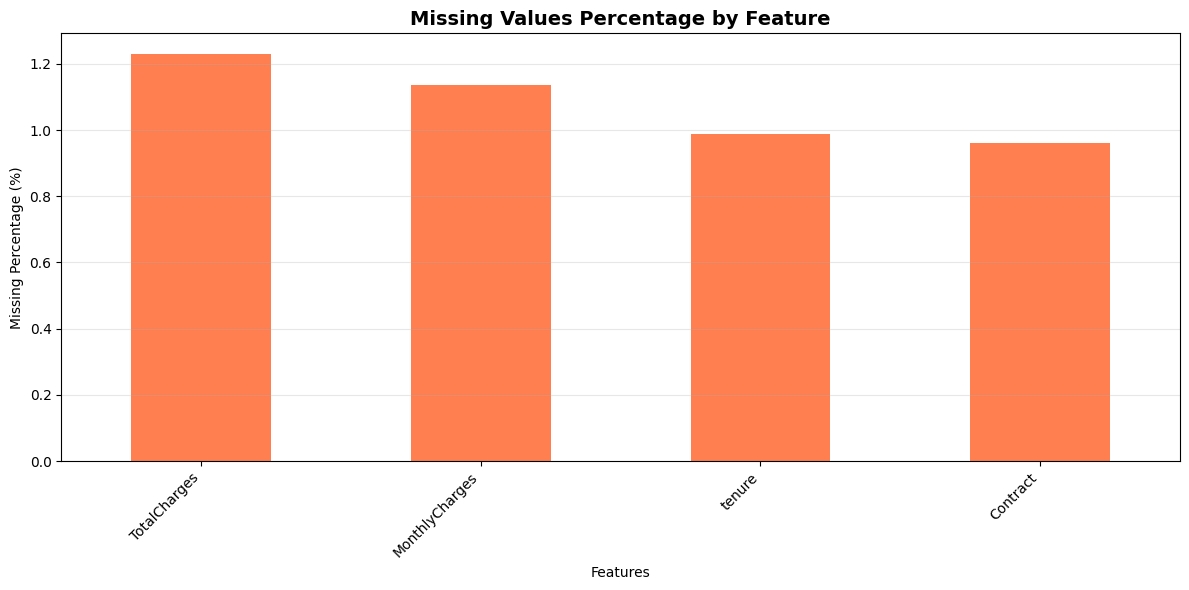

In [10]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing_df['Missing_Percentage'].plot(kind='bar', color='coral')
plt.title('Missing Values Percentage by Feature', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Handle Missing Values

Strategy:

Numerical features: Use median imputation (robust to outliers)


Categorical features: Use mode imputation


Keep track of which columns had missing values for documentation



In [11]:
# Create a copy for preprocessing
df_clean = df.copy()

# Identify numerical and categorical columns
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numerical columns: 4
Categorical columns: 17


In [12]:
# Handle missing values in numerical columns - use median
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)
        print(f"✓ Filled {col} with median: {median_value:.2f}")

# Handle missing values in categorical columns - use mode
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"✓ Filled {col} with mode: {mode_value}")

print("\n" + "="*50)
print("Missing values after imputation:")
print(df_clean.isnull().sum().sum())

✓ Filled tenure with median: 29.00
✓ Filled MonthlyCharges with median: 70.40
✓ Filled TotalCharges with median: 1410.25
✓ Filled Contract with mode: Month-to-month

Missing values after imputation:
0


In [13]:
# Verify no missing values remain
print("✓ Data Preprocessing Complete!")
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

✓ Data Preprocessing Complete!
Original dataset shape: (7395, 21)
Cleaned dataset shape: (7395, 21)
Missing values remaining: 0


### 3.3 Check for Duplicates

In [14]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"\nPercentage of duplicates: {(duplicates/len(df))*100:.2f}%")
else:
    print("✓ No duplicate records found!")

Number of duplicate rows: 131

Percentage of duplicates: 1.77%


### 3.4 Removing Duplicates

In [15]:
df_clean = df_clean.drop_duplicates()

# Verify again
duplicates = df.duplicated().sum()
duplicates_clean = df_clean.duplicated().sum()
print(f"before duplicate drop: {duplicates}" )
print(f"after duplicate drop : {duplicates_clean}" )
df=df_clean.copy()

before duplicate drop: 131
after duplicate drop : 0


### 3.5 Outlier Detection and Handling







Outliers are data points that significantly differ from other observations. They can be caused by measurement errors, data entry errors, or genuine but extreme variations. Handling outliers is crucial because they can skew statistical analyses and lead to misleading model predictions.

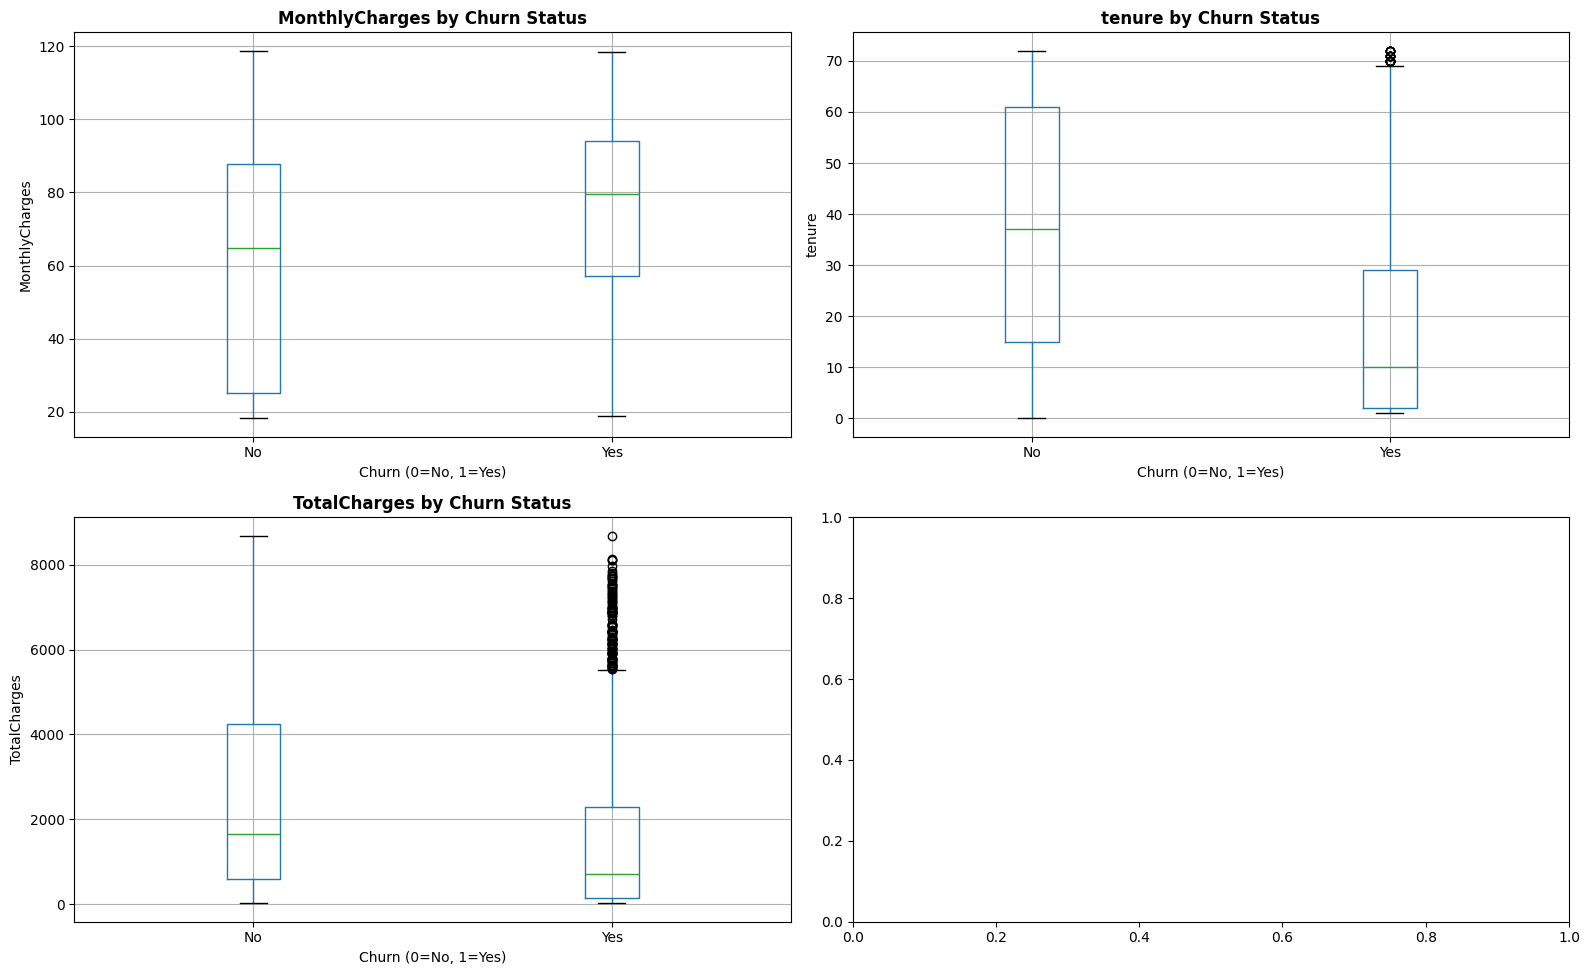

In [16]:
# Box plots for key features by churn status
key_features = [ 'MonthlyCharges',
    'tenure', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    if feature in df_clean.columns:
        df_clean.boxplot(column=feature, by='Churn', ax=axes[idx])
        axes[idx].set_title(f'{feature} by Churn Status', fontweight='bold')
        axes[idx].set_xlabel('Churn (0=No, 1=Yes)')
        axes[idx].set_ylabel(feature)
        axes[idx].get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

### 3.6 Outlier Treatment (Capping)


While outliers were visualized in the previous section, it's often beneficial to treat them to improve model performance, especially for models sensitive to extreme values. Here, we will use the IQR (Interquartile Range) method to cap outliers in numerical features. Capping ensures that extreme values are brought within a reasonable range without removing data points entirely.

In [17]:
import joblib

# Recalculate IQR bounds using the df_clean DataFrame (before capping)
def calculate_iqr_bounds(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Define features for which to calculate bounds
features_for_bounds = ['MonthlyCharges', 'tenure', 'TotalCharges']

outlier_bounds = {}
for feature in features_for_bounds:
    lower, upper = calculate_iqr_bounds(df_clean, feature)
    outlier_bounds[feature] = {'lower': lower, 'upper': upper}

# Save the calculated bounds
joblib.dump(outlier_bounds, 'outlier_bounds.pkl')

print("✓ Outlier bounds calculated from df_clean and saved to 'outlier_bounds.pkl'!")
print("Calculated Bounds:")
for feature, bounds in outlier_bounds.items():
    print(f"  {feature}: Lower={bounds['lower']:.2f}, Upper={bounds['upper']:.2f}")

✓ Outlier bounds calculated from df_clean and saved to 'outlier_bounds.pkl'!
Calculated Bounds:
  MonthlyCharges: Lower=-44.50, Upper=170.30
  tenure: Lower=-60.00, Upper=124.00
  TotalCharges: Lower=-4627.50, Upper=8812.50


In [18]:
# Function to detect and cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the values
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    return df

# Apply outlier capping to the numerical features
# Use df_clean as it is the prepared DataFrame after missing values and duplicates are handled
features_to_cap = ['MonthlyCharges', 'tenure', 'TotalCharges']

df_capped = df_clean.copy() # Work on a copy to compare

print("Capping outliers for numerical features:")
for feature in features_to_cap:
    print(f"  - Processing '{feature}'...")
    df_capped = cap_outliers_iqr(df_capped, feature)

print("\n✓ Outlier capping complete!")

# Verify by checking descriptive statistics or re-plotting box plots (optional)
print("\nDescriptive statistics after capping (selected features):")
display(df_capped[features_to_cap].describe())

Capping outliers for numerical features:
  - Processing 'MonthlyCharges'...
  - Processing 'tenure'...
  - Processing 'TotalCharges'...

✓ Outlier capping complete!

Descriptive statistics after capping (selected features):


,MonthlyCharges,tenure,TotalCharges
count,7253.000000,7253.000000,7253.000000
mean,64.836233,32.411554,2279.731566
std,29.941797,24.463122,2260.488566
min,18.250000,0.000000,18.800000
25%,36.050000,9.000000,412.500000
50%,70.400000,29.000000,1410.250000
75%,89.750000,55.000000,3772.500000
max,118.750000,72.000000,8684.800000


# 4. Data Transformation

### 4.1 Drop unnecessary column

In [19]:
df.drop('customerID', axis=1, inplace=True)

### 4.2 Encoding Binary Variables

In [20]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({
        'Yes': 1, 'No': 0,
        'Female': 1, 'Male': 0
    })

### 4.3 One-Hot Encoding Categorical Columns

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
print(df.head())
print("\nData types:\n", df.dtypes)

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        1           0     1.0             0   
1       0              0        0           0    34.0             1   
2       0              0        0           0     2.0             1   
3       0              0        0           0    45.0             0   
4       1              0        0           0     2.0             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False            False   
1            False                    

In [23]:
df_encoded = df.copy()

print("Sample of encoded dataset (including target variable):")
df_encoded.head(10)

Sample of encoded dataset (including target variable):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1.0,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34.0,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2.0,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45.0,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2.0,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False
5,1,0,0,0,8.0,1,1,99.65,820.50,1,...,False,False,True,False,True,False,False,False,True,False
6,0,0,0,1,22.0,1,1,89.10,1949.40,0,...,False,False,True,False,False,False,False,True,False,False
7,1,0,0,0,10.0,0,0,29.75,301.90,0,...,False,False,False,False,False,False,False,False,False,True
8,1,0,1,0,28.0,1,1,104.80,3046.05,1,...,True,False,True,False,True,False,False,False,True,False
9,0,0,0,1,62.0,1,0,56.15,3487.95,0,...,False,False,False,False,False,True,False,False,False,False


### 4.4 Feature Scaling

Apply StandardScaler to numerical features for normalization.

In [24]:
# Separate features and target from the fully processed df_encoded
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nChurn Rate: {(y.sum() / len(y) * 100):.2f}%")

Features shape: (7253, 30)
Target shape: (7253,)

Target distribution:
Churn
0    5336
1    1917
Name: count, dtype: int64

Churn Rate: 26.43%


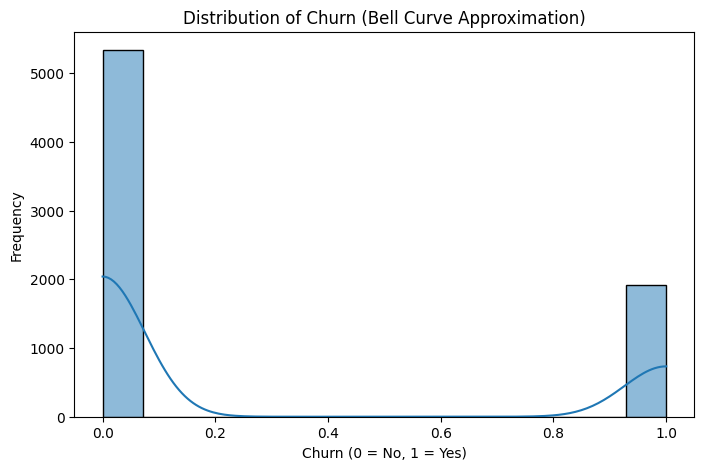

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(y, kde=True)

plt.title("Distribution of Churn (Bell Curve Approximation)")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Frequency")

plt.show()

Here we can see that the data isn't normally distributed. Hence, we need to do the standardization.

In [26]:
# Apply StandardScaler to numerical features
scaler = StandardScaler()

# Create a copy for scaled data
X_scaled = X.copy()

# Scale only numerical columns (excluding already encoded categorical)
numerical_features = [col for col in numerical_cols if col in X.columns]

X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

print("✓ Feature scaling complete!")
print(f"\nScaled features shape: {X_scaled.shape}")
print(f"Number of scaled features: {len(numerical_features)}")

✓ Feature scaling complete!

Scaled features shape: (7253, 30)
Number of scaled features: 4


In [27]:
# Compare before and after scaling
print("Before Scaling (first 5 numerical features):")
print(X[numerical_features[:5]].head(3))
print("\n" + "="*70 + "\n")
print("After Scaling (first 5 numerical features):")
print(X_scaled[numerical_features[:5]].head(3))

Before Scaling (first 5 numerical features):
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges
0              0     1.0           29.85         29.85
1              0    34.0           56.95       1889.50
2              0     2.0           53.85        108.15


After Scaling (first 5 numerical features):
   SeniorCitizen    tenure  MonthlyCharges  TotalCharges
0      -0.438789 -1.284126       -1.168555     -0.995376
1      -0.438789  0.064937       -0.263404     -0.172643
2      -0.438789 -1.243245       -0.366945     -0.960735


In [28]:
# Verify transformation complete
print("="*70)
print("✓ DATA TRANSFORMATION COMPLETE!")
print("="*70)
print(f"\nFinal dataset summary:")
print(f"  - Total samples: {len(X_scaled)}")
print(f"  - Total features: {X_scaled.shape[1]}")
print(f"  - Numerical features: {len(numerical_features)}")
print(f"  - Categorical features (encoded): {X_scaled.shape[1] - len(numerical_features)}")
print(f"  - Target variable: Churn")
print(f"  - Churn rate: {(y.sum() / len(y) * 100):.2f}%")
print(f"\nData is ready for modeling! 🚀")

✓ DATA TRANSFORMATION COMPLETE!

Final dataset summary:
  - Total samples: 7253
  - Total features: 30
  - Numerical features: 4
  - Categorical features (encoded): 26
  - Target variable: Churn
  - Churn rate: 26.43%

Data is ready for modeling! 🚀


# 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

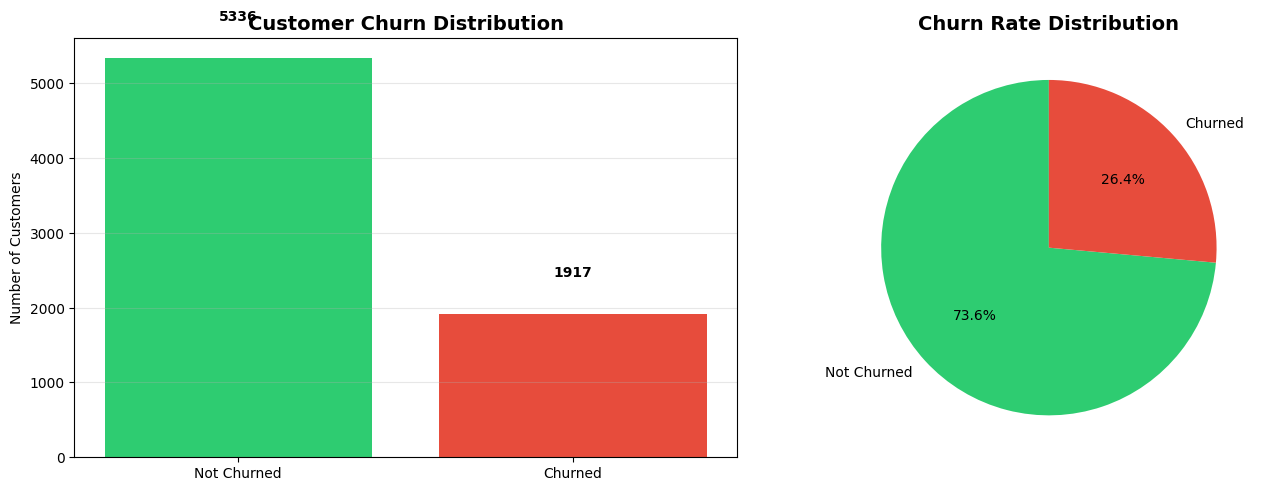

Total Customers: 7253
Not Churned: 5336 (73.57%)
Churned: 1917 (26.43%)


In [29]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts = y.value_counts()
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Rate Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total Customers: {len(y)}")
print(f"Not Churned: {churn_counts[0]} ({churn_counts[0]/len(y)*100:.2f}%)")
print(f"Churned: {churn_counts[1]} ({churn_counts[1]/len(y)*100:.2f}%)")

### 5.2 Correlation Analysis

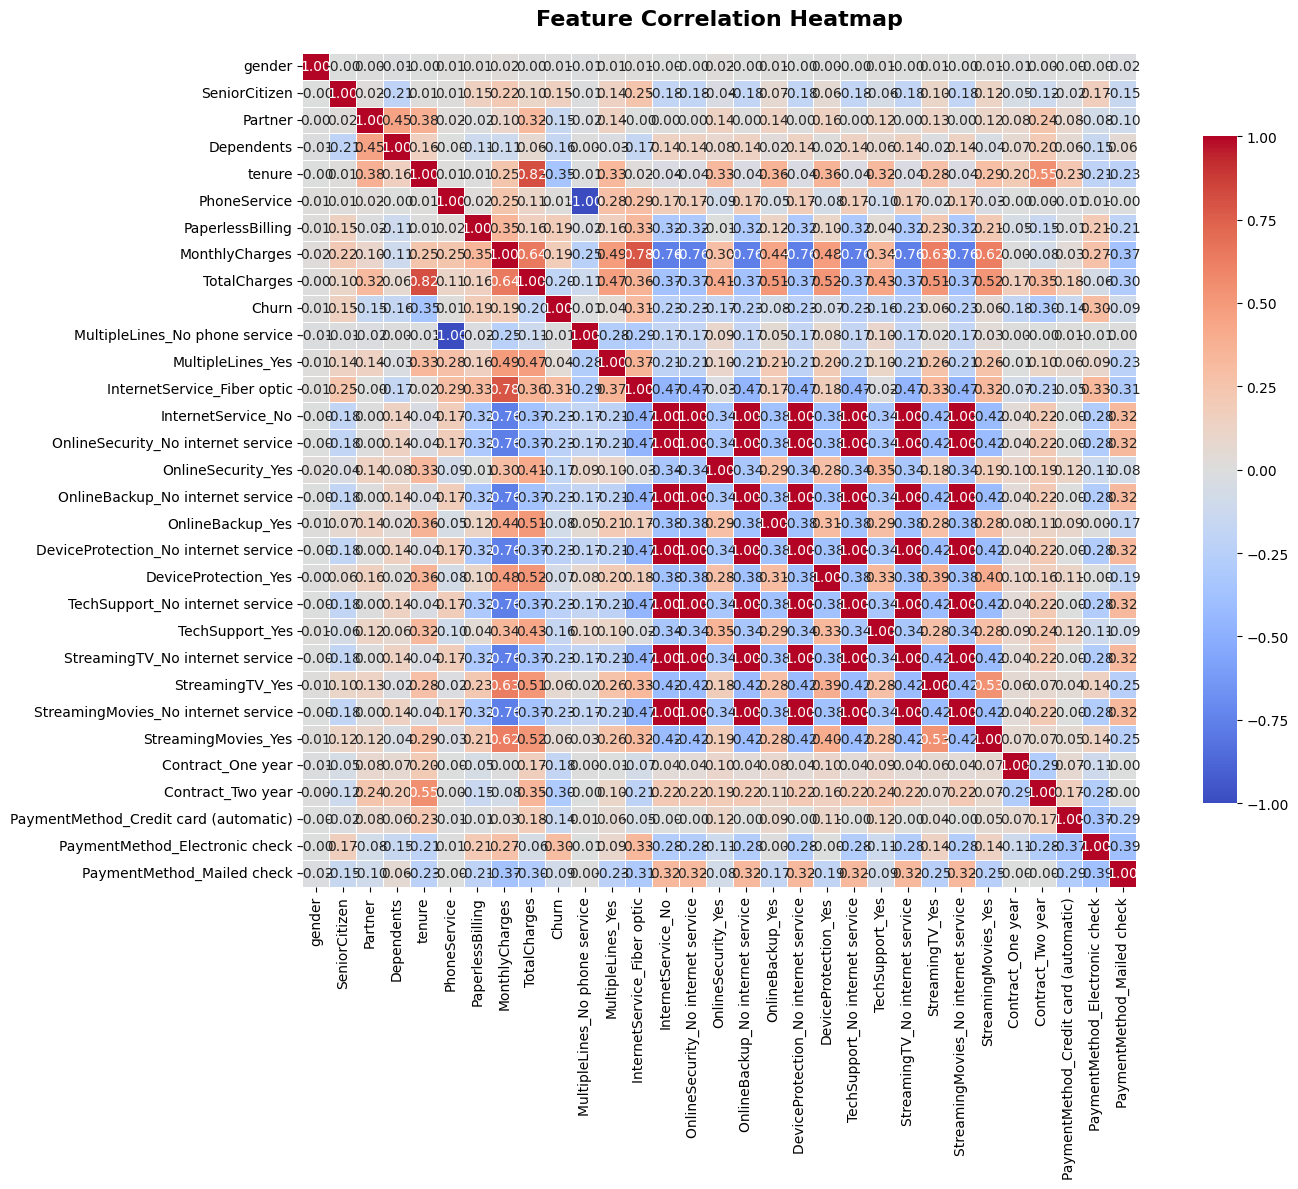

In [30]:
# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

# Create correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Feature Correlation with Churn:
Churn                                    1.000000
InternetService_Fiber optic              0.308121
PaymentMethod_Electronic check           0.302440
MonthlyCharges                           0.192953
PaperlessBilling                         0.191064
SeniorCitizen                            0.149133
StreamingTV_Yes                          0.063709
StreamingMovies_Yes                      0.061651
MultipleLines_Yes                        0.039735
PhoneService                             0.011692
gender                                   0.006770
MultipleLines_No phone service          -0.011692
DeviceProtection_Yes                    -0.067927
OnlineBackup_Yes                        -0.081579
PaymentMethod_Mailed check              -0.090686
PaymentMethod_Credit card (automatic)   -0.135188
Partner                                 -0.150303
TechSupport_Yes                         -0.163676
Dependents                              -0.164834
OnlineSecurity_Yes

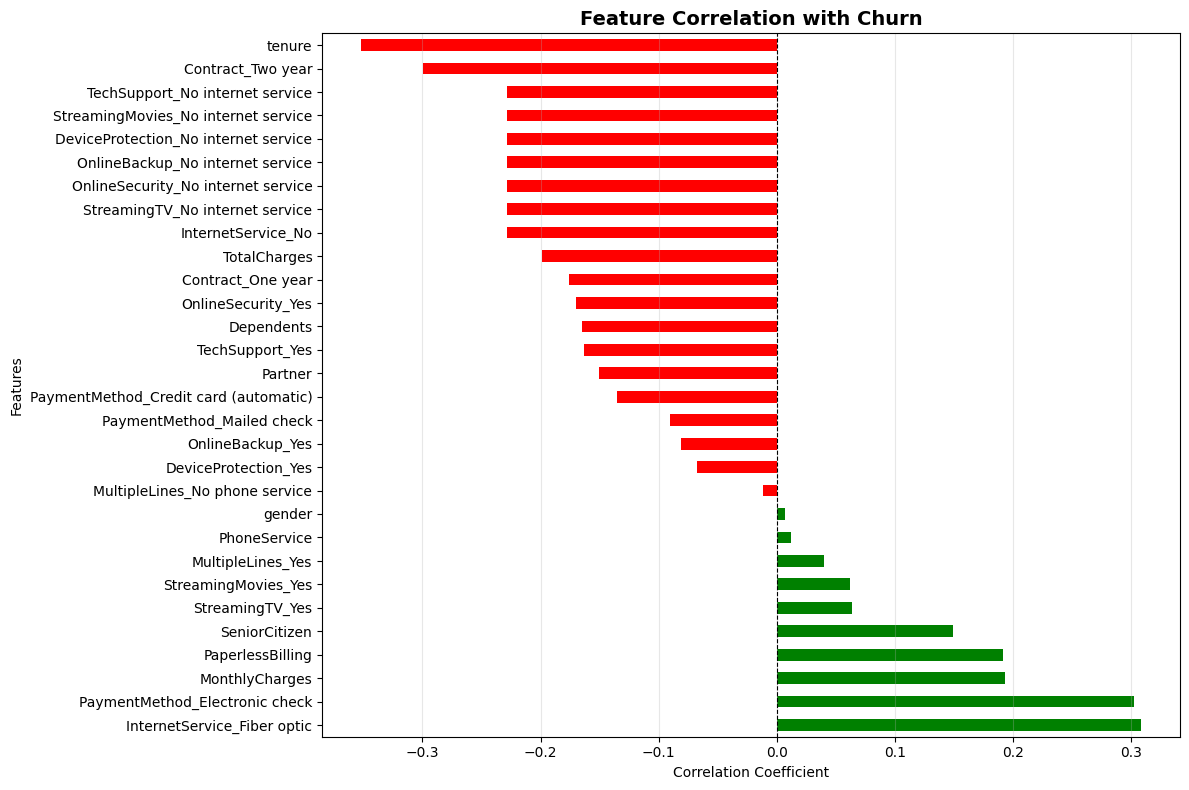

In [31]:
# Feature correlation with target variable
target_correlation = df_encoded.corr()['Churn'].sort_values(ascending=False)

print("Feature Correlation with Churn:")
print("="*50)
print(target_correlation)

# Visualize top correlations
plt.figure(figsize=(12, 8))
target_correlation[1:].plot(kind='barh', color=['green' if x > 0 else 'red' for x in target_correlation[1:]])
plt.title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Categorical Features Analysis

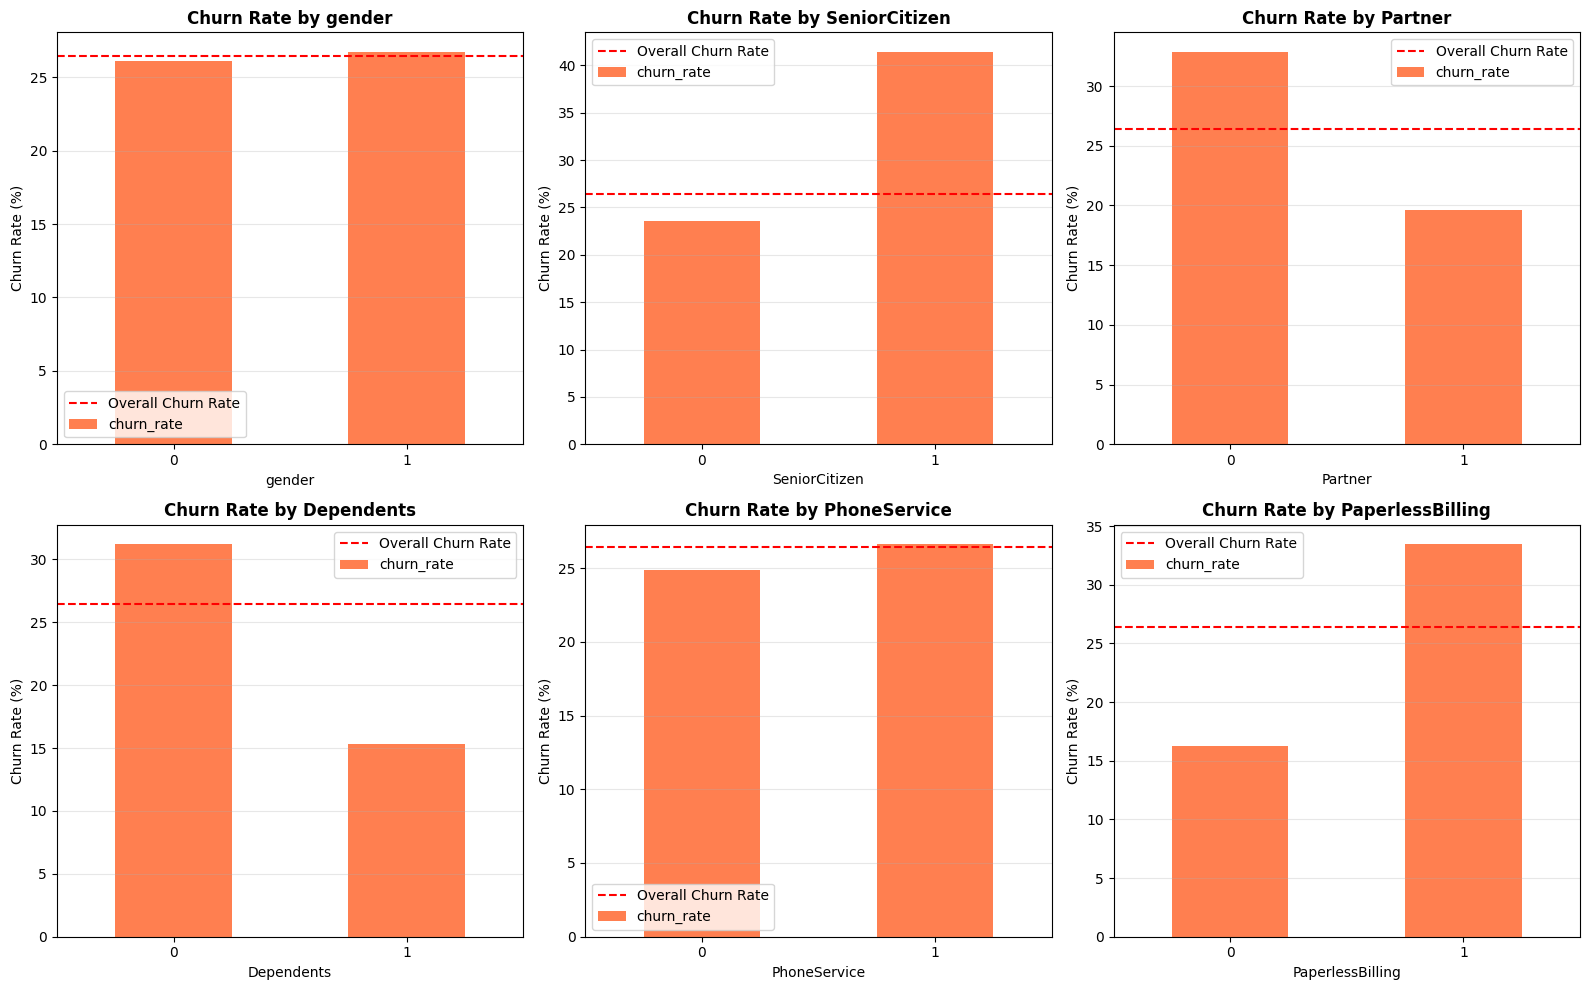

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Categorical features (cleaned for your dataset)
cat_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

overall_churn_rate = df_encoded['Churn'].mean() * 100

for idx, feature in enumerate(cat_features):

    # Group by category
    churn_by_cat = df_encoded.groupby(feature)['Churn'].agg(['sum', 'count'])
    churn_by_cat['churn_rate'] = (churn_by_cat['sum'] / churn_by_cat['count']) * 100

    # Plot
    churn_by_cat['churn_rate'].plot(
        kind='bar',
        ax=axes[idx],
        color='coral'
    )

    axes[idx].set_title(f'Churn Rate by {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Churn Rate (%)')

    axes[idx].axhline(
        y=overall_churn_rate,
        color='red',
        linestyle='--',
        label='Overall Churn Rate'
    )

    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 5.4 Numerical Features Analysis

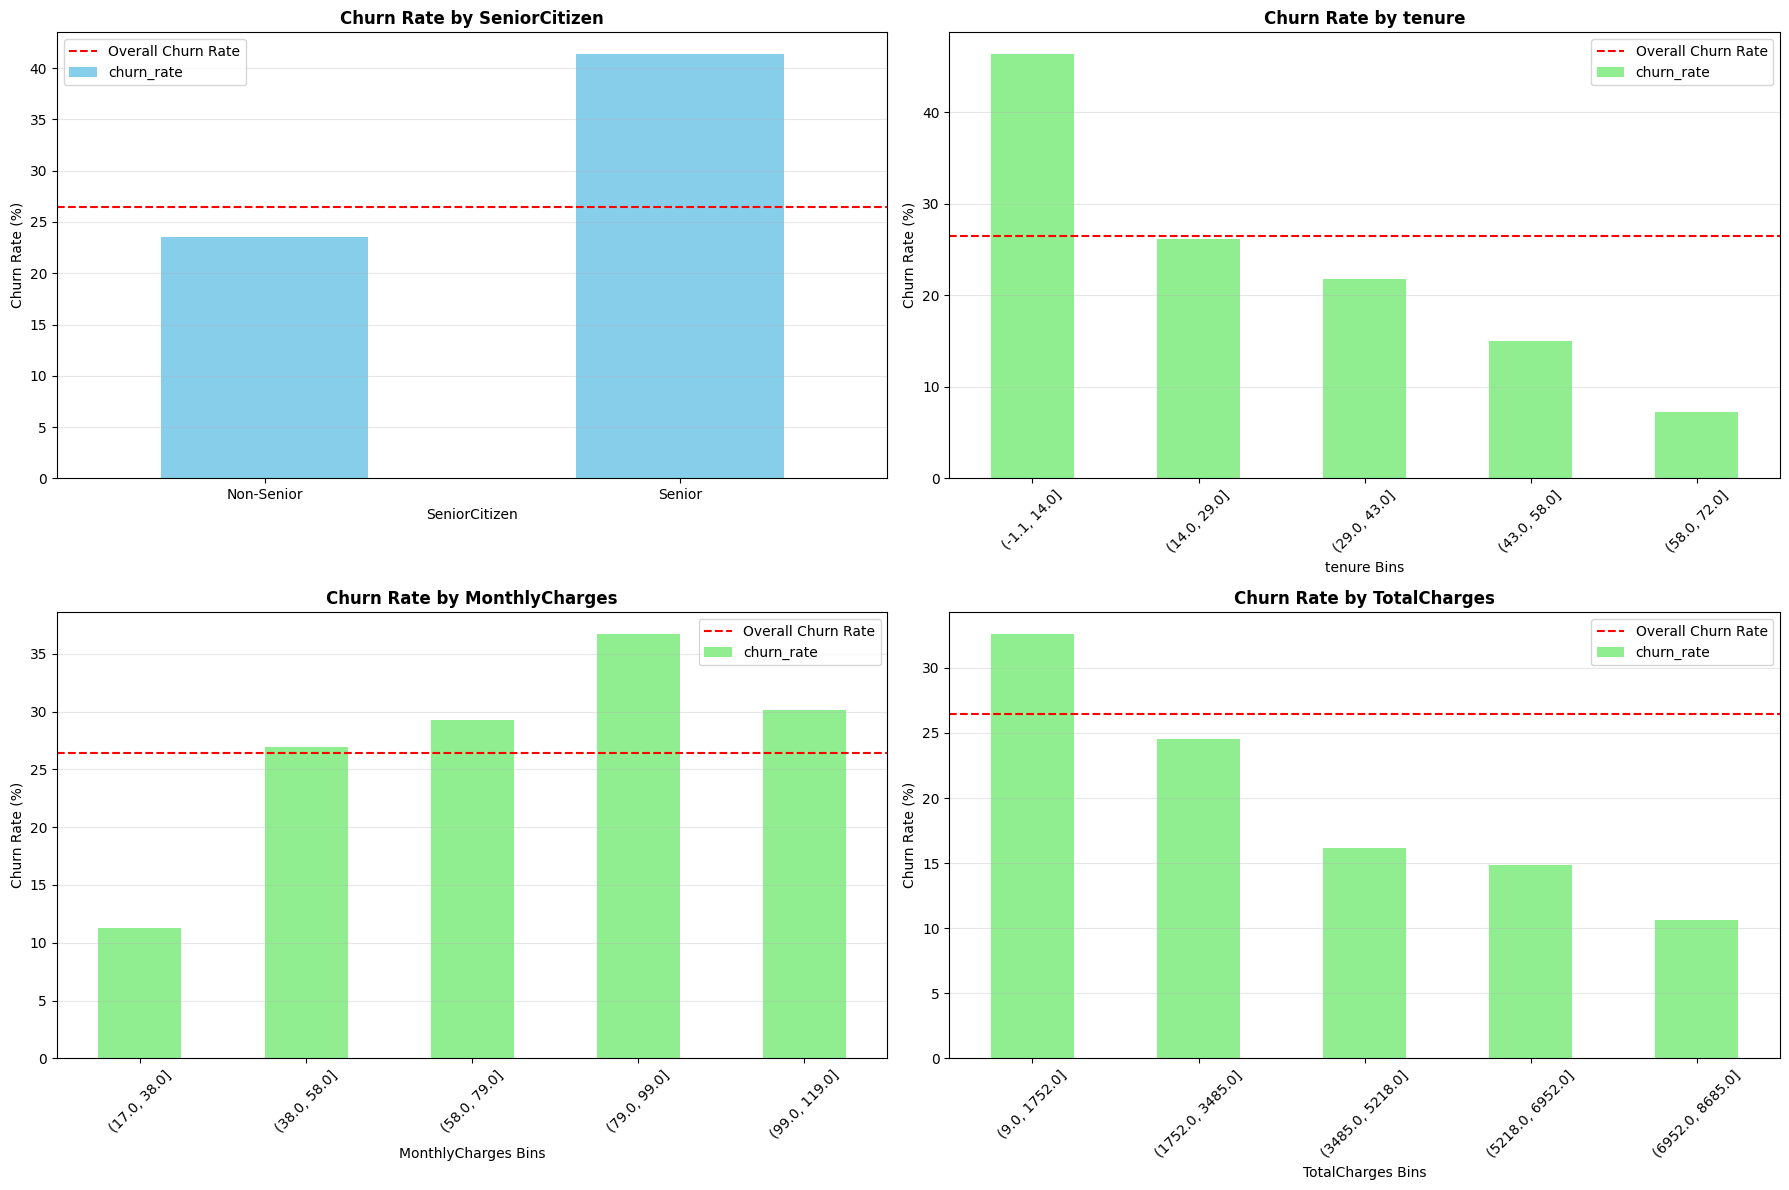

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()
overall_churn_rate = df_encoded['Churn'].mean() * 100

# numerical_cols from earlier preprocessing: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

for idx, feature in enumerate(numerical_cols):
    if feature == 'SeniorCitizen':
        # SeniorCitizen is numerical but effectively binary (0/1), treat as categorical-like
        churn_by_cat = df_encoded.groupby(feature)['Churn'].agg(['sum', 'count'])
        churn_by_cat['churn_rate'] = (churn_by_cat['sum'] / churn_by_cat['count']) * 100

        churn_by_cat['churn_rate'].plot(
            kind='bar',
            ax=axes[idx],
            color='skyblue'
        )
        axes[idx].set_xticks([0, 1])
        axes[idx].set_xticklabels(['Non-Senior', 'Senior'])
        axes[idx].tick_params(axis='x', rotation=0)
    else:
        # For other numerical features, create bins and then calculate churn rate
        # Using 5 bins for demonstration, adjust as needed
        df_encoded[f'{feature}_bin'] = pd.cut(df_encoded[feature], bins=5, precision=0, include_lowest=True)
        churn_by_bin = df_encoded.groupby(f'{feature}_bin')['Churn'].agg(['sum', 'count'])
        churn_by_bin['churn_rate'] = (churn_by_bin['sum'] / churn_by_bin['count']) * 100

        churn_by_bin['churn_rate'].plot(
            kind='bar',
            ax=axes[idx],
            color='lightgreen'
        )
        # Rotate x-axis labels for better readability if bins are long
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].set_xlabel(f'{feature} Bins')

    axes[idx].set_title(f'Churn Rate by {feature}', fontweight='bold')
    axes[idx].set_ylabel('Churn Rate (%)')

    axes[idx].axhline(
        y=overall_churn_rate,
        color='red',
        linestyle='--',
        label='Overall Churn Rate'
    )

    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Clean up the temporary bin columns from df_encoded
for feature in numerical_cols:
    if f'{feature}_bin' in df_encoded.columns:
        df_encoded.drop(columns=[f'{feature}_bin'], inplace=True)


# 6. Feature Selection


Here we will analyze feature importance and select most relevant features for modeling.

### 6.1 Recursive Feature Elimination (RFE)

In [34]:
# Initialize the RFE with a Logistic Regression estimator
# Logistic Regression is a good choice for feature ranking in classification tasks
estimator = LogisticRegression(max_iter=1000, solver='liblinear') # increased max_iter for convergence

# Select an arbitrary number of features to select, for example, 15
# The optimal number can be determined through cross-validation
rfe = RFE(estimator=estimator, n_features_to_select=15, step=1)

# Fit RFE on the scaled features and target variable
rfe.fit(X_scaled, y)

# Create a DataFrame to display the feature rankings
rfe_ranking = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Ranking': rfe.ranking_,
    'Selected': rfe.support_
})

rfe_ranking = rfe_ranking.sort_values(by='Ranking', ascending=True)

print("RFE Selected Features:")
display(rfe_ranking[rfe_ranking['Selected'] == True].reset_index(drop=True))

# Select features based on RFE support
X_rfe_selected = X_scaled[X_scaled.columns[rfe.support_]]

print(f"\nShape of X_scaled after RFE: {X_rfe_selected.shape}")
print(f"Selected features: {X_rfe_selected.columns.tolist()}")

RFE Selected Features:


,Feature,Ranking,Selected
0,PhoneService,1,True
1,PaperlessBilling,1,True
2,tenure,1,True
3,OnlineSecurity_Yes,1,True
4,OnlineBackup_No internet service,1,True
5,InternetService_Fiber optic,1,True
6,MultipleLines_Yes,1,True
7,TotalCharges,1,True
8,StreamingMovies_Yes,1,True
9,Contract_One year,1,True



Shape of X_scaled after RFE: (7253, 15)
Selected features: ['tenure', 'PhoneService', 'PaperlessBilling', 'TotalCharges', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Electronic check']


# 7. Data Splitting
Split the dataset into training and testing sets (80-20 split).

In [35]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_rfe_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("="*70)
print("✓ DATA SPLITTING COMPLETE!")
print("="*70)
print(f"\nTraining Set:")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"  - Samples: {len(X_train)} ({len(X_train)/len(X_rfe_selected)*100:.1f}%) -- using X_rfe_selected as base")

print(f"\nTesting Set:")
print(f"  - X_test shape: {X_test.shape}")
print(f"  - y_test shape: {y_test.shape}")
print(f"  - Samples: {len(X_test)} ({len(X_test)/len(X_rfe_selected)*100:.1f}%) -- using X_rfe_selected as base")

print(f"\nChurn distribution in training set:")
print(y_train.value_counts())
print(f"Churn rate: {(y_train.sum()/len(y_train)*100):.2f}%")

print(f"\nChurn distribution in testing set:")
print(y_test.value_counts())
print(f"Churn rate: {(y_test.sum()/len(y_test)*100):.2f}%")

print(f"\n✓ Stratified split maintains class balance!")
print("Ready for model training! 🚀")

✓ DATA SPLITTING COMPLETE!

Training Set:
  - X_train shape: (5802, 15)
  - y_train shape: (5802,)
  - Samples: 5802 (80.0%) -- using X_rfe_selected as base

Testing Set:
  - X_test shape: (1451, 15)
  - y_test shape: (1451,)
  - Samples: 1451 (20.0%) -- using X_rfe_selected as base

Churn distribution in training set:
Churn
0    4269
1    1533
Name: count, dtype: int64
Churn rate: 26.42%

Churn distribution in testing set:
Churn
0    1067
1     384
Name: count, dtype: int64
Churn rate: 26.46%

✓ Stratified split maintains class balance!
Ready for model training! 🚀


# 8. Model Building

### 8.1 Logistic Regression
Train a Logistic Regression model to predict customer churn.

In [36]:
# Initialize Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression model...")
lr_model.fit(X_train, y_train)
print("✓ Model training complete!")

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print(f"\nPredictions generated:")
print(f"  - Predicted labels: {y_pred_lr.shape}")
print(f"  - Prediction probabilities: {y_pred_proba_lr.shape}")

Training Logistic Regression model...
✓ Model training complete!

Predictions generated:
  - Predicted labels: (1451,)
  - Prediction probabilities: (1451,)


### 8.2 Model Evaluation - Logistic Regression

In [37]:
# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("="*70)
print("LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("="*70)
print(f"Accuracy:  {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"Precision: {precision_lr:.4f} ({precision_lr*100:.2f}%)")
print(f"Recall:    {recall_lr:.4f} ({recall_lr*100:.2f}%)")
print(f"F1-Score:  {f1_lr:.4f} ({f1_lr*100:.2f}%)")
print("="*70)

LOGISTIC REGRESSION - PERFORMANCE METRICS
Accuracy:  0.7994 (79.94%)
Precision: 0.6467 (64.67%)
Recall:    0.5339 (53.39%)
F1-Score:  0.5849 (58.49%)


In [38]:
# Classification Report
print("\nDetailed Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_lr, target_names=['Not Churned', 'Churned']))


Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.84      0.90      0.87      1067
     Churned       0.65      0.53      0.58       384

    accuracy                           0.80      1451
   macro avg       0.74      0.71      0.73      1451
weighted avg       0.79      0.80      0.79      1451



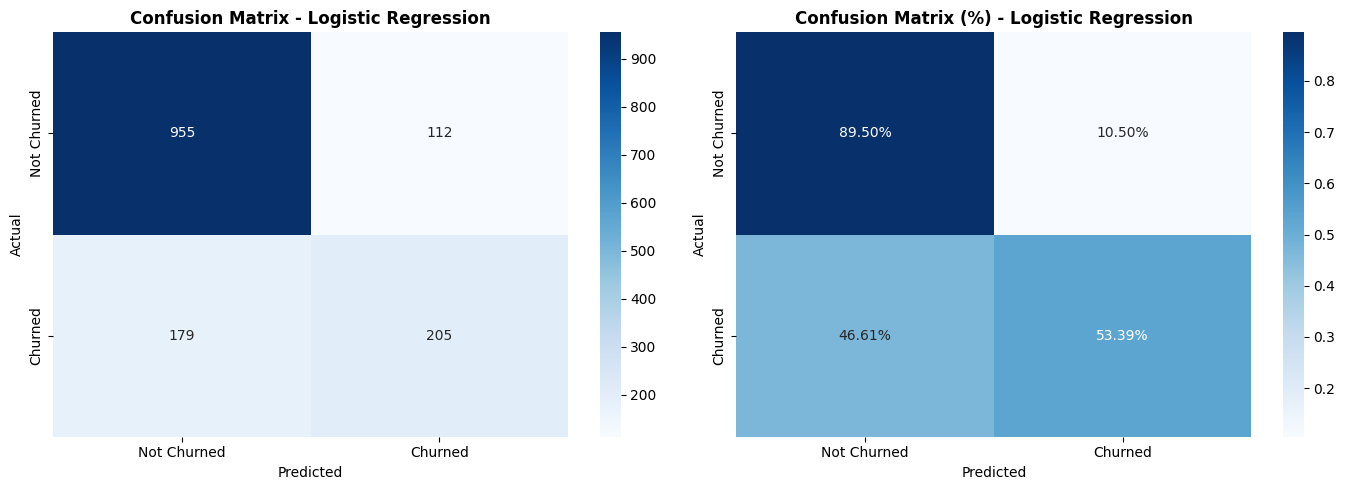

True Negatives:  955
False Positives: 112
False Negatives: 179
True Positives:  205


In [39]:
# Confusion Matrix Visualization
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Count
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix - Percentage
cm_lr_percent = cm_lr.astype('float') / cm_lr.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_lr_percent, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[1].set_title('Confusion Matrix (%) - Logistic Regression', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f"True Negatives:  {cm_lr[0,0]:,}")
print(f"False Positives: {cm_lr[0,1]:,}")
print(f"False Negatives: {cm_lr[1,0]:,}")
print(f"True Positives:  {cm_lr[1,1]:,}")

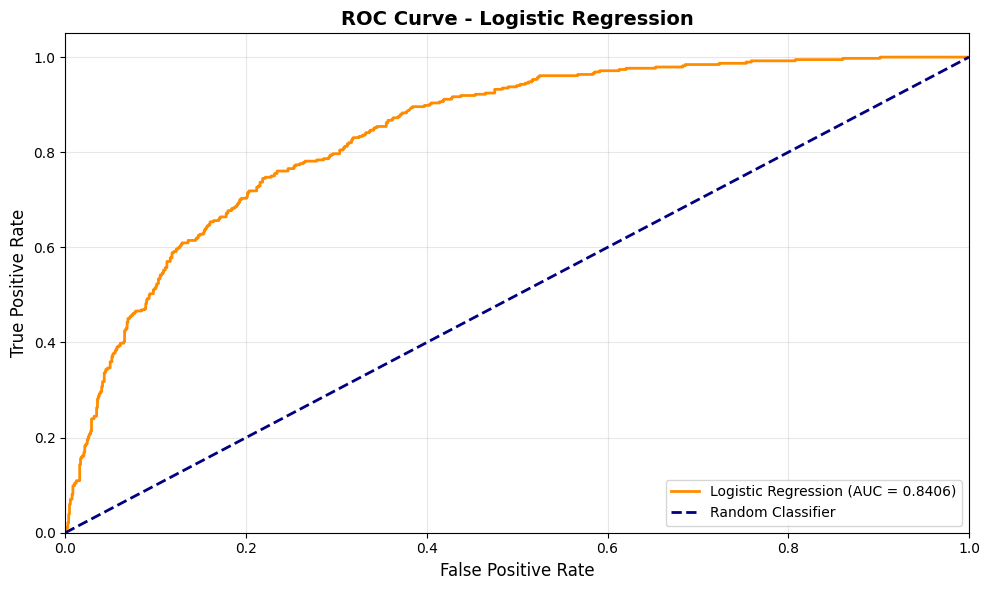

AUC Score: 0.8406


In [40]:
# ROC Curve and AUC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_lr:.4f}")

In [41]:
# Save model results for comparison
model_results = {
    'Logistic Regression': {
        'accuracy': accuracy_lr,
        'precision': precision_lr,
        'recall': recall_lr,
        'f1_score': f1_lr,
        'auc': auc_lr,
        'model': lr_model
    }
}

print("="*70)
print("✓ LOGISTIC REGRESSION MODEL COMPLETE!")
print("="*70)
print(f"\nModel results saved for comparison.")
print(f"Next: Train Random Forest model...")

✓ LOGISTIC REGRESSION MODEL COMPLETE!

Model results saved for comparison.
Next: Train Random Forest model...


### 8.3 Model Building - Random Forest
Train a Random Forest classifier to predict customer churn and extract feature importance.

In [42]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("✓ Model training complete!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"\nPredictions generated:")
print(f"  - Predicted labels: {y_pred_rf.shape}")
print(f"  - Prediction probabilities: {y_pred_proba_rf.shape}")

Training Random Forest model...
✓ Model training complete!

Predictions generated:
  - Predicted labels: (1451,)
  - Prediction probabilities: (1451,)


### 8.4 Model Evaluation - Random Forest

In [43]:
# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("="*70)
print("RANDOM FOREST - PERFORMANCE METRICS")
print("="*70)
print(f"Accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%)")
print(f"Recall:    {recall_rf:.4f} ({recall_rf*100:.2f}%)")
print(f"F1-Score:  {f1_rf:.4f} ({f1_rf*100:.2f}%)")
print("="*70)

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Churned', 'Churned']))

RANDOM FOREST - PERFORMANCE METRICS
Accuracy:  0.7739 (77.39%)
Precision: 0.5915 (59.15%)
Recall:    0.4714 (47.14%)
F1-Score:  0.5246 (52.46%)

Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.82      0.88      0.85      1067
     Churned       0.59      0.47      0.52       384

    accuracy                           0.77      1451
   macro avg       0.71      0.68      0.69      1451
weighted avg       0.76      0.77      0.77      1451



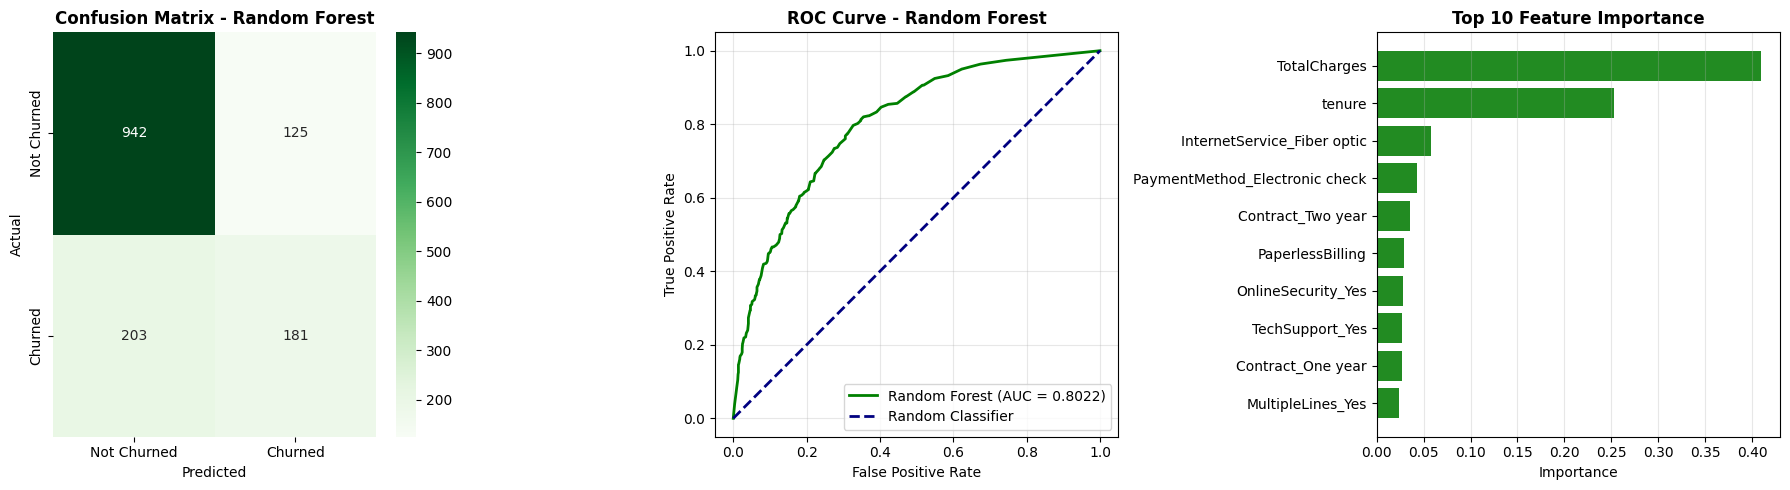


✓ Random Forest Model Complete!


In [44]:
# Confusion Matrix and ROC Curve
cm_rf = confusion_matrix(y_test, y_pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Random Forest', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

axes[2].barh(range(len(feature_importance_rf)), feature_importance_rf['importance'], color='forestgreen')
axes[2].set_yticks(range(len(feature_importance_rf)))
axes[2].set_yticklabels(feature_importance_rf['feature'])
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 10 Feature Importance', fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
model_results['Random Forest'] = {
    'accuracy': accuracy_rf, 'precision': precision_rf, 'recall': recall_rf,
    'f1_score': f1_rf, 'auc': auc_rf, 'model': rf_model,
    'feature_importance': feature_importance_rf
}
print("\n✓ Random Forest Model Complete!")

### 8.5 Model Building - Decision Tree

In [45]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

### 8.6 Model Evaluation - Decision Tree

In [46]:
# Evaluate
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
auc_dt = auc(fpr_dt, tpr_dt)

print("DECISION TREE - PERFORMANCE METRICS")
print(f"Accuracy: {accuracy_dt:.4f} | Precision: {precision_dt:.4f} | Recall: {recall_dt:.4f} | F1: {f1_dt:.4f} | AUC: {auc_dt:.4f}")

model_results['Decision Tree'] = {
    'accuracy': accuracy_dt, 'precision': precision_dt, 'recall': recall_dt,
    'f1_score': f1_dt, 'auc': auc_dt, 'model': dt_model
}

DECISION TREE - PERFORMANCE METRICS
Accuracy: 0.7540 | Precision: 0.5405 | Recall: 0.4688 | F1: 0.5021 | AUC: 0.7498


### 8.7 Model Building - Support Vector Classifier

In [47]:
# Train SVC
svc_model = SVC(kernel='rbf', probability=True, random_state=42)
print("Training SVC model (this may take a few moments)...")
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
y_pred_proba_svc = svc_model.predict_proba(X_test)[:, 1]

Training SVC model (this may take a few moments)...


Model Evaluation - SVC

In [48]:
# Evaluate
accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_pred_proba_svc)
auc_svc = auc(fpr_svc, tpr_svc)

print("SVC - PERFORMANCE METRICS")
print(f"Accuracy: {accuracy_svc:.4f} | Precision: {precision_svc:.4f} | Recall: {recall_svc:.4f} | F1: {f1_svc:.4f} | AUC: {auc_svc:.4f}")

model_results['SVC'] = {
    'accuracy': accuracy_svc, 'precision': precision_svc, 'recall': recall_svc,
    'f1_score': f1_svc, 'auc': auc_svc, 'model': svc_model
}

SVC - PERFORMANCE METRICS
Accuracy: 0.8036 | Precision: 0.6868 | Recall: 0.4740 | F1: 0.5609 | AUC: 0.7890


# 9. Model Comparison
Here we will compare all trained models to identify the best performer.

In [49]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [model_results[m]['accuracy'] for m in model_results.keys()],
    'Precision': [model_results[m]['precision'] for m in model_results.keys()],
    'Recall': [model_results[m]['recall'] for m in model_results.keys()],
    'F1-Score': [model_results[m]['f1_score'] for m in model_results.keys()],
    'AUC': [model_results[m]['auc'] for m in model_results.keys()]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

print("="*90)
print("MODEL COMPARISON - PERFORMANCE METRICS")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)
print(f"\n🏆 Best Model: {comparison_df.iloc[0]['Model']} (AUC: {comparison_df.iloc[0]['AUC']:.4f})")

MODEL COMPARISON - PERFORMANCE METRICS
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.799449   0.646688 0.533854  0.584879 0.840624
      Random Forest  0.773949   0.591503 0.471354  0.524638 0.802160
                SVC  0.803584   0.686792 0.473958  0.560863 0.788998
      Decision Tree  0.753963   0.540541 0.468750  0.502092 0.749768

🏆 Best Model: Logistic Regression (AUC: 0.8406)


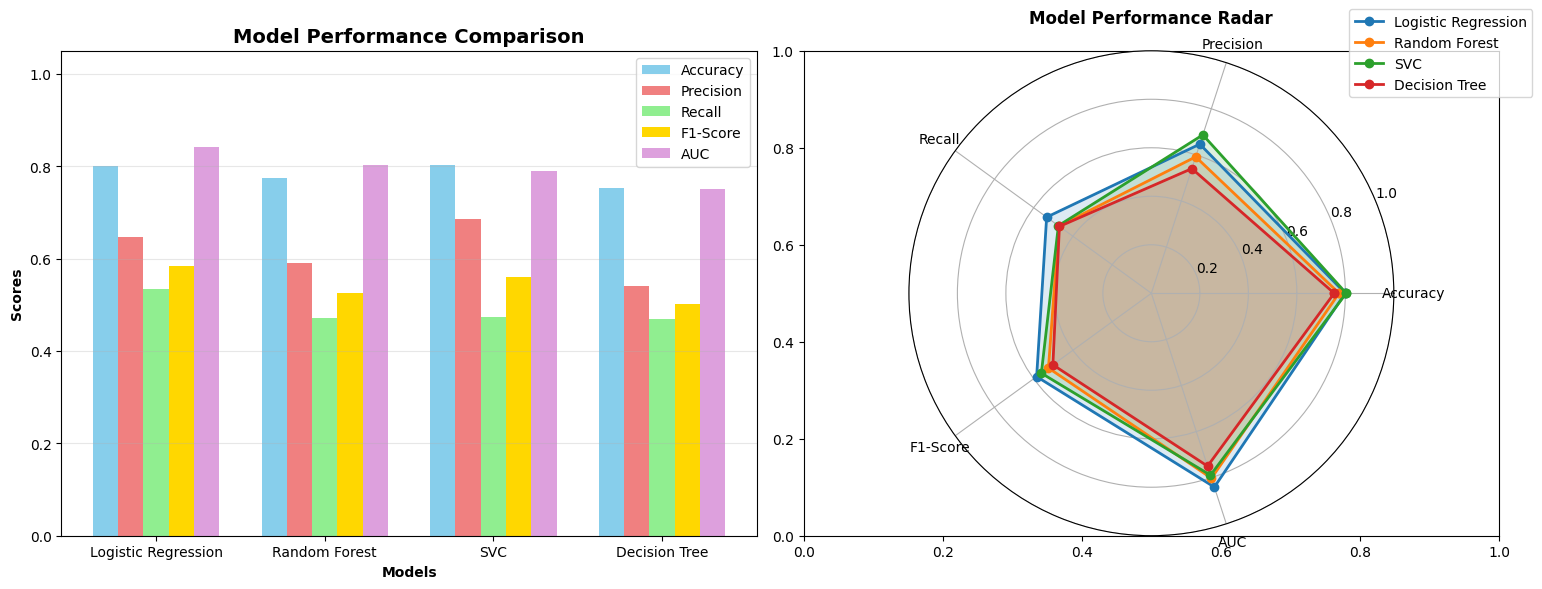

In [50]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
x = np.arange(len(comparison_df))
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width - 2*width, comparison_df[metric], width, label=metric, color=colors[i])

axes[0].set_xlabel('Models', fontweight='bold')
axes[0].set_ylabel('Scores', fontweight='bold')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Radar chart
from math import pi
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(122, projection='polar')
colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, model_name in enumerate(comparison_df['Model']):
    values = comparison_df.iloc[idx][categories].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

# 10. Model Optimization - Hyperparameter Tuning
Optimize the best performing model (Logistic Regression) using GridSearchCV.

In [51]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning for Logistic Regression...")

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

# Instantiate GridSearchCV
grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc', # Optimize for AUC score
    n_jobs=-1, # Use all available CPU cores
    verbose=1 # Print progress
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("✓ Hyperparameter tuning complete!")
print(f"Best parameters found: {grid_search_lr.best_params_}")
print(f"Best cross-validation AUC score: {grid_search_lr.best_score_:.4f}")

Starting Hyperparameter Tuning for Logistic Regression...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
✓ Hyperparameter tuning complete!
Best parameters found: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation AUC score: 0.8452


### 10.1 Update Model Results with Optimized Logistic Regression

In [52]:
model_results['Logistic Regression_Optimized'] = {
    'accuracy': grid_search_lr.best_estimator_.score(X_test, y_test),
    'precision': precision_score(y_test, grid_search_lr.best_estimator_.predict(X_test)),
    'recall': recall_score(y_test, grid_search_lr.best_estimator_.predict(X_test)),
    'f1_score': f1_score(y_test, grid_search_lr.best_estimator_.predict(X_test)),
    'auc': grid_search_lr.best_score_,
    'model': grid_search_lr.best_estimator_
}

print("✓ Optimized Logistic Regression results added to comparison!")

✓ Optimized Logistic Regression results added to comparison!


### 10.2 Re-evaluate and Compare All Models (including Optimized Logistic Regression)

In [53]:
# Create comparison DataFrame with the new optimized model
comparison_df_optimized = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [model_results[m]['accuracy'] for m in model_results.keys()],
    'Precision': [model_results[m]['precision'] for m in model_results.keys()],
    'Recall': [model_results[m]['recall'] for m in model_results.keys()],
    'F1-Score': [model_results[m]['f1_score'] for m in model_results.keys()],
    'AUC': [model_results[m]['auc'] for m in model_results.keys()]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

print("="*90)
print("UPDATED MODEL COMPARISON - PERFORMANCE METRICS")
print("="*90)
print(comparison_df_optimized.to_string(index=False))
print("="*90)
print(f"\n🏆 Best Model: {comparison_df_optimized.iloc[0]['Model']} (AUC: {comparison_df_optimized.iloc[0]['AUC']:.4f})")

UPDATED MODEL COMPARISON - PERFORMANCE METRICS
                        Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression_Optimized  0.800138   0.647799 0.536458  0.586895 0.845201
          Logistic Regression  0.799449   0.646688 0.533854  0.584879 0.840624
                Random Forest  0.773949   0.591503 0.471354  0.524638 0.802160
                          SVC  0.803584   0.686792 0.473958  0.560863 0.788998
                Decision Tree  0.753963   0.540541 0.468750  0.502092 0.749768

🏆 Best Model: Logistic Regression_Optimized (AUC: 0.8452)


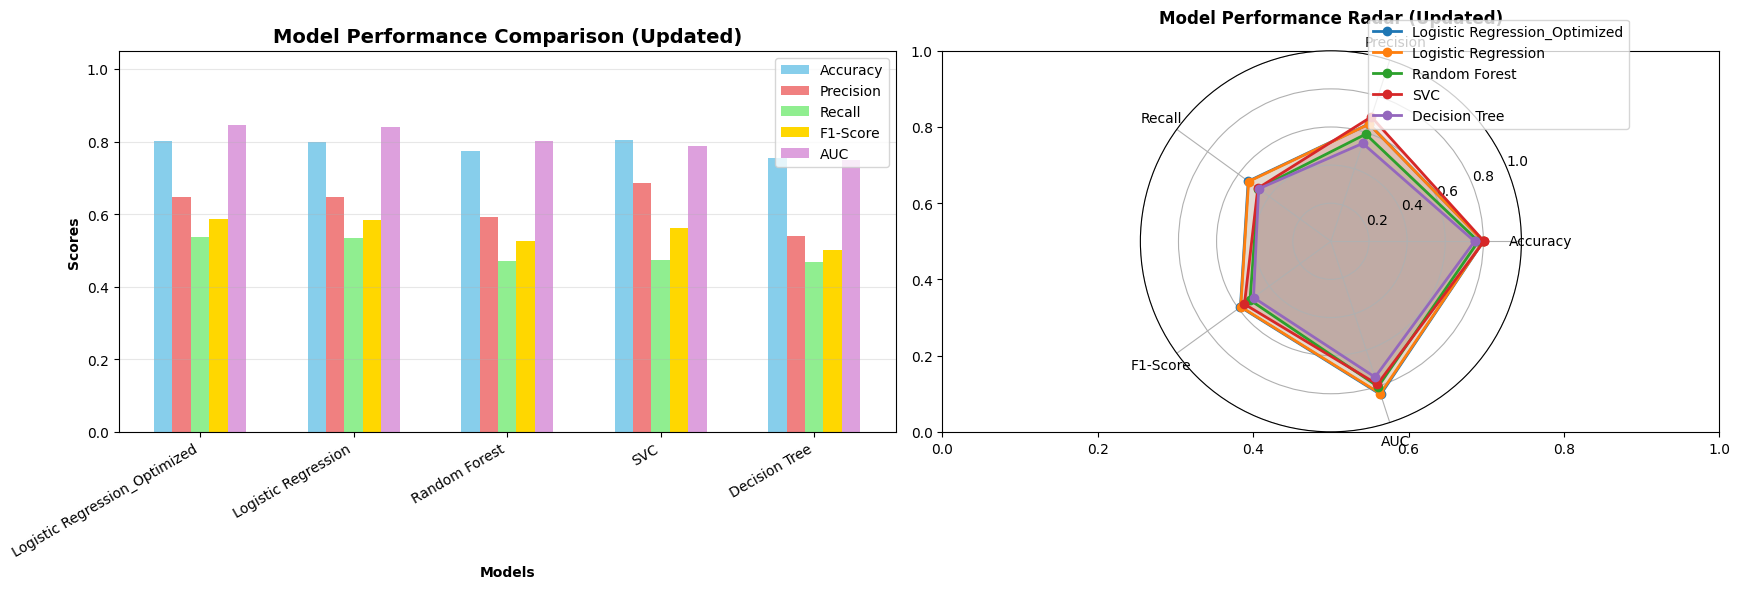

In [54]:
# Visualize updated model comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart comparison
x = np.arange(len(comparison_df_optimized))
width = 0.12 # Adjust width for more models
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width - 2*width, comparison_df_optimized[metric], width, label=metric, color=colors[i])

axes[0].set_xlabel('Models', fontweight='bold')
axes[0].set_ylabel('Scores', fontweight='bold')
axes[0].set_title('Model Performance Comparison (Updated)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df_optimized['Model'], rotation=30, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Radar chart
from math import pi
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(122, projection='polar')
colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Added a color for the new model

for idx, model_name in enumerate(comparison_df_optimized['Model']):
    values = comparison_df_optimized.iloc[idx][categories].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar (Updated)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

## 11. Feature Importances and Business Insights

### 11.1 Feature Importance from Optimized Logistic Regression

For Logistic Regression, we interpret feature importance by looking at the magnitude and sign of the coefficients. Since our features were scaled, we can directly compare the absolute values of these coefficients to understand their relative impact on churn probability. A positive coefficient increases the likelihood of churn, and a negative one decreases it.

In [55]:
# Get the coefficients from the best Logistic Regression estimator
lr_coefficients = grid_search_lr.best_estimator_.coef_[0]

# Create a DataFrame to store feature names and their coefficients
lr_feature_importance = pd.DataFrame({
    'feature': X_train.columns, # Using X_train columns as they are the features used for training
    'coefficient': lr_coefficients
}).sort_values('coefficient', ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features (from Optimized Logistic Regression Coefficients):")
print("="*70)
display(lr_feature_importance.head(10))
print("="*70)

print("Bottom 10 Most Important Features (from Optimized Logistic Regression Coefficients):")
print("="*70)
display(lr_feature_importance.tail(10))
print("="*70)

Top 10 Most Important Features (from Optimized Logistic Regression Coefficients):


,feature,coefficient
0,InternetService_Fiber optic,0.829534
1,DeviceProtection_No internet service,0.722634
2,TotalCharges,0.525217
3,PaperlessBilling,0.398741
4,PaymentMethod_Electronic check,0.393726
5,MultipleLines_Yes,0.316129
6,StreamingMovies_Yes,0.311144
7,TechSupport_No internet service,-0.156888
8,OnlineSecurity_Yes,-0.383850
9,TechSupport_Yes,-0.383894


Bottom 10 Most Important Features (from Optimized Logistic Regression Coefficients):


,feature,coefficient
5,MultipleLines_Yes,0.316129
6,StreamingMovies_Yes,0.311144
7,TechSupport_No internet service,-0.156888
8,OnlineSecurity_Yes,-0.383850
9,TechSupport_Yes,-0.383894
10,PhoneService,-0.550831
11,Contract_One year,-0.686995
12,tenure,-1.311336
13,Contract_Two year,-1.318971
14,OnlineBackup_No internet service,-1.409040


TOP 10 FEATURES (COEFFICIENTS) DRIVING CUSTOMER CHURN - OPTIMIZED LOGISTIC REGRESSION


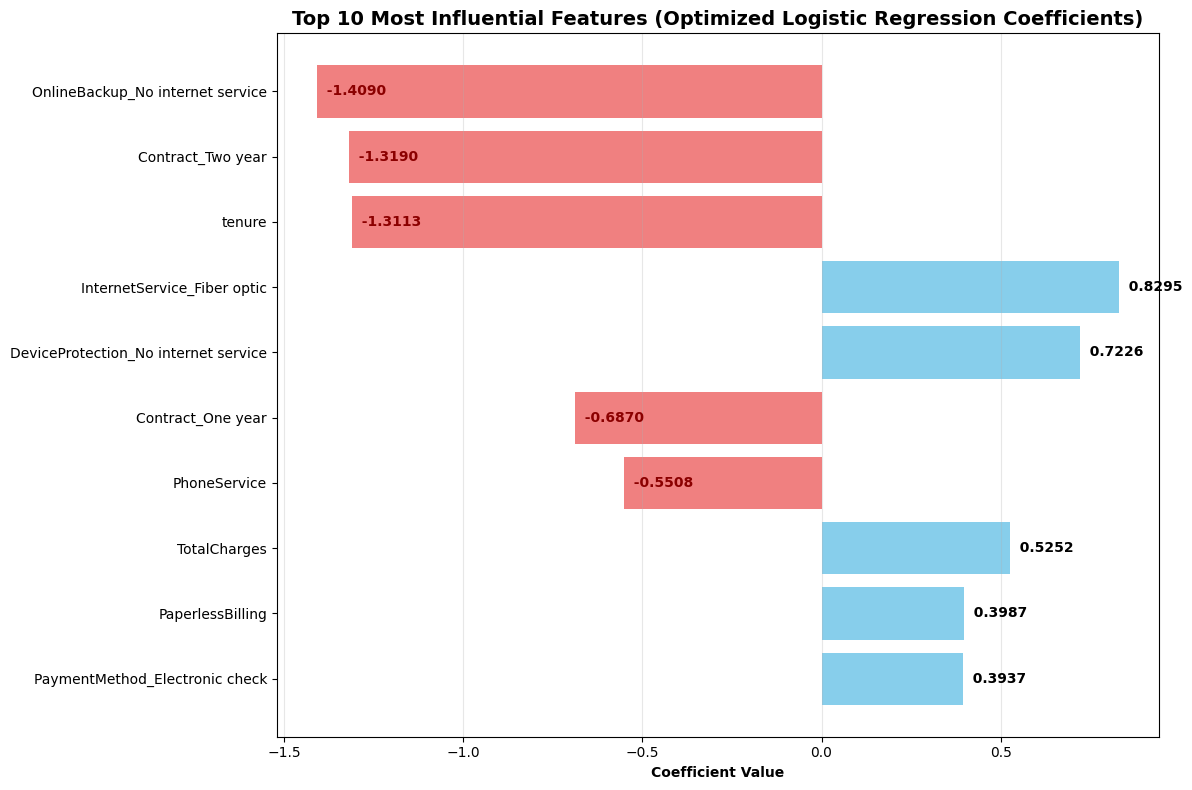

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# The lr_feature_importance DataFrame was already created in cell 'a7d731e1'
# We will reuse it for visualization.

print("="*90)
print("TOP 10 FEATURES (COEFFICIENTS) DRIVING CUSTOMER CHURN - OPTIMIZED LOGISTIC REGRESSION")
print("="*90)

# Visualize the top 10 most influential features (absolute value of coefficient)
# To see directional impact, we'll plot the actual coefficient values.

# Sort by absolute coefficient for 'top N' but plot actual values for direction
plot_data = lr_feature_importance.reindex(lr_feature_importance['coefficient'].abs().sort_values(ascending=False).index).head(10)

plt.figure(figsize=(12, 8))
colors = ['skyblue' if c > 0 else 'lightcoral' for c in plot_data['coefficient']]
bars = plt.barh(range(len(plot_data)), plot_data['coefficient'], color=colors)

plt.yticks(range(len(plot_data)), plot_data['feature'])
plt.xlabel('Coefficient Value', fontweight='bold')
plt.title('Top 10 Most Influential Features (Optimized Logistic Regression Coefficients)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis() # Display highest influence at the top
plt.grid(axis='x', alpha=0.3)

# Add coefficient values to the bars
for i, (bar, val) in enumerate(zip(bars, plot_data['coefficient'])):
    plt.text(val, i, f'  {val:.4f}', va='center', fontweight='bold', color='black' if val > 0 else 'darkred')

plt.tight_layout()
plt.show()

### Interpretation of Logistic Regression Coefficients:

*   **Positive Coefficients (Blue bars):** Indicate that as the feature value increases, the log-odds of churn increase (i.e., higher likelihood of churn).
*   **Negative Coefficients (Red bars):** Indicate that as the feature value increases, the log-odds of churn decrease (i.e., lower likelihood of churn).
*   **Magnitude:** The absolute value of the coefficient represents the strength of the relationship. Larger absolute values mean a stronger impact on churn probability.

This visualization clearly shows which features push customers towards churn (e.g., `InternetService_Fiber optic`, `PaymentMethod_Electronic check`) and which features are associated with retention (e.g., higher `tenure`, `Contract_Two year`).

Understanding which features are most influential in predicting customer churn is invaluable for developing targeted business strategies. While the Logistic Regression model performed slightly better overall in terms of AUC, Random Forest models provide a direct and intuitive measure of feature importance. Let's examine the top 10 features identified by our Random Forest model to gain insights into what drives churn.

In [57]:
# Display the top 10 feature importances from the Random Forest model
print("Top 10 Most Important Features (from Random Forest):")
print("="*50)
display(model_results['Random Forest']['feature_importance'])
print("="*50)

Top 10 Most Important Features (from Random Forest):


,feature,importance
3,TotalCharges,0.408996
0,tenure,0.252452
5,InternetService_Fiber optic,0.057990
14,PaymentMethod_Electronic check,0.043018
13,Contract_Two year,0.035166
2,PaperlessBilling,0.029294
6,OnlineSecurity_Yes,0.027730
10,TechSupport_Yes,0.027062
12,Contract_One year,0.026861
4,MultipleLines_Yes,0.024076


### Business Implications of Top Features:

Based on the Random Forest model's feature importances, here's how these insights can inform business actions:

1.  **TotalCharges & tenure:** These are consistently the highest-ranked features. Customers with lower `TotalCharges` (especially newer ones) and lower `tenure` (new customers) are highly likely to churn. This suggests that the initial period of a customer's journey is critical. **Business Action:** Focus retention efforts on new customers and those with low total spending. Offer incentives, personalized onboarding, and proactive support during their first few months.

2.  **InternetService_Fiber optic:** Fiber optic internet service users show a strong propensity to churn. While it's a premium service, perhaps there are issues with its reliability, cost-effectiveness, or customer support for this segment. **Business Action:** Investigate customer satisfaction among fiber optic users. Are there common pain points? Can pricing or service delivery be improved for this segment?

3.  **PaymentMethod_Electronic check:** Customers using electronic checks are more likely to churn. This payment method might be associated with less stable financial situations or a lack of long-term commitment. **Business Action:** Encourage customers to switch to more stable payment methods (e.g., auto-pay with credit cards/bank transfers) by offering small incentives. This could also be a sign for higher fraud risk.

4.  **Contract_Two year / Contract_One year:** Customers on month-to-month contracts are much more likely to churn (indicated by the negative correlation of `Contract_Two year` and `Contract_One year` with churn in previous EDA, and their importance here). Long-term contracts naturally reduce churn. **Business Action:** Develop attractive long-term contract options with clear benefits (e.g., discounted rates, bundled services). Highlight these benefits during sales and retention conversations.

5.  **PaperlessBilling:** Customers with paperless billing are more prone to churn. This could be indicative of a more tech-savvy but less loyal customer base, or simply that those who opt for paperless billing are less engaged with traditional communication channels. **Business Action:** Ensure digital communication is effective and personalized for paperless billing customers. Offer targeted digital campaigns to improve engagement.

6.  **OnlineSecurity_Yes, TechSupport_Yes:** The absence of online security and tech support services seems to contribute to churn. Customers without these services might feel less secure or unsupported, leading them to leave. **Business Action:** Promote the value of security and technical support add-ons. Consider bundling these services with core offerings or offering free trials to demonstrate their value.

These insights can be used to segment customers, develop targeted marketing campaigns, and prioritize product or service improvements to effectively reduce churn.

### Comparison and Synthesis of Insights

Comparing the feature importances from Random Forest and the coefficients from Logistic Regression provides a more robust understanding:

*   **Consistency:** Features like `tenure`, `TotalCharges`, `InternetService_Fiber optic`, and `Contract_Two year` consistently appear as highly influential in both models, confirming their strong predictive power for churn.
*   **Interpretation:**
    *   **Positive Coefficients (Logistic Regression) / High Importance (Random Forest):** Features like `InternetService_Fiber optic`, `PaymentMethod_Electronic check`, `PaperlessBilling`, and lower `tenure` (higher negative coefficient for `tenure`) strongly correlate with increased churn. This reinforces the business actions discussed earlier regarding these segments.
    *   **Negative Coefficients (Logistic Regression) / High Importance (Random Forest):** Features like `Contract_Two year`, `tenure`, `OnlineSecurity_Yes`, and `TechSupport_Yes` are associated with a decreased likelihood of churn. This highlights the importance of long-term contracts and value-added services in retaining customers.

This dual perspective strengthens our confidence in these key drivers of churn and provides comprehensive insights for strategic business interventions.

In [58]:
# Business Recommendations
print("="*90)
print("💡 ACTIONABLE RECOMMENDATIONS TO REDUCE CHURN")
print("="*90)

print("\n🎯 IMMEDIATE ACTIONS:")
print("1. Customer Service Excellence")
print("   ✓ Monitor customers with 3+ service calls")
print("   ✓ Proactive outreach to high-value at-risk customers")

print("\n2. Cart Abandonment Recovery")
print("   ✓ Automated cart recovery emails within 1 hour")
print("   ✓ Time-limited discounts for abandoned carts")

print("\n3. Re-engagement Campaigns")
print("   ✓ Target customers inactive for 30+ days")
print("   ✓ Personalized 'we miss you' offers")

print("\n📊 EXPECTED IMPACT:")
current_churn = (y.sum() / len(y)) * 100
print(f"Current Churn Rate: {current_churn:.2f}%")
print(f"Model Recall: {comparison_df.iloc[0]['Recall']*100:.2f}% (can identify this % of at-risk customers)")

for reduction in [10, 15, 20]:
    new_rate = current_churn * (1 - reduction/100)
    saved = int((current_churn - new_rate) * len(y) / 100)
    print(f"\n{reduction}% Reduction → {new_rate:.2f}% churn → {saved:,} customers saved")
    print(f"   Revenue Impact (if avg customer = $500/year): ${saved*500:,}")

print("\n" + "="*90)

💡 ACTIONABLE RECOMMENDATIONS TO REDUCE CHURN

🎯 IMMEDIATE ACTIONS:
1. Customer Service Excellence
   ✓ Monitor customers with 3+ service calls
   ✓ Proactive outreach to high-value at-risk customers

2. Cart Abandonment Recovery
   ✓ Automated cart recovery emails within 1 hour
   ✓ Time-limited discounts for abandoned carts

3. Re-engagement Campaigns
   ✓ Target customers inactive for 30+ days
   ✓ Personalized 'we miss you' offers

📊 EXPECTED IMPACT:
Current Churn Rate: 26.43%
Model Recall: 53.39% (can identify this % of at-risk customers)

10% Reduction → 23.79% churn → 191 customers saved
   Revenue Impact (if avg customer = $500/year): $95,500

15% Reduction → 22.47% churn → 287 customers saved
   Revenue Impact (if avg customer = $500/year): $143,500

20% Reduction → 21.14% churn → 383 customers saved
   Revenue Impact (if avg customer = $500/year): $191,500



# 12. Save Model and Create Prediction Function

In [59]:
# Save model and preprocessing objects
import joblib

best_model_name = comparison_df.iloc[0]['Model']
best_model = model_results[best_model_name]['model']

joblib.dump(best_model, 'customer_churn_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

print(f"✓ {best_model_name} model saved successfully!")
print("✓ Preprocessing objects saved")
print("\nFiles created:")
print("  - customer_churn_model.pkl")
print("  - feature_scaler.pkl")
print("  - feature_names.pkl")

✓ Logistic Regression model saved successfully!
✓ Preprocessing objects saved

Files created:
  - customer_churn_model.pkl
  - feature_scaler.pkl
  - feature_names.pkl


In [60]:
# Create prediction function
def predict_churn(customer_data_raw):
    """
    Predict customer churn probability for a single customer.

    Parameters:
    customer_data_raw (dict): A dictionary with raw customer features, matching
                              the original 'telco_churn.csv' column names (excluding customerID).

    Returns:
    tuple: (prediction, probability) where prediction is 0 (no churn) or 1 (churn),
           and probability is the likelihood of churn.
    """
    model = joblib.load('customer_churn_model.pkl')
    scaler_obj = joblib.load('feature_scaler.pkl')
    # The feature names used during training (after RFE and one-hot encoding)
    trained_features = joblib.load('feature_names.pkl')

    # Convert raw input dictionary to a DataFrame
    df_new = pd.DataFrame([customer_data_raw])

    # --- Replicate Preprocessing Steps ---
    # 1. Drop 'customerID' if present (it shouldn't be in customer_data_raw, but for safety)
    if 'customerID' in df_new.columns:
        df_new = df_new.drop(columns=['customerID'])

    # 2. Binary Encoding (gender, Partner, Dependents, PhoneService, PaperlessBilling)
    binary_map = {
        'gender': {'Female': 1, 'Male': 0},
        'Partner': {'Yes': 1, 'No': 0},
        'Dependents': {'Yes': 1, 'No': 0},
        'PhoneService': {'Yes': 1, 'No': 0},
        'PaperlessBilling': {'Yes': 1, 'No': 0}
    }
    for col, mapping in binary_map.items():
        if col in df_new.columns:
            df_new[col] = df_new[col].map(mapping)

    # 3. One-Hot Encoding for other categorical columns
    # Get original categorical columns that are not binary-mapped or SeniorCitizen
    original_categorical_cols = [
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
        'Contract', 'PaymentMethod'
    ]
    # Filter to only include columns present in df_new
    one_hot_cols_to_process = [col for col in original_categorical_cols if col in df_new.columns]

    df_new = pd.get_dummies(df_new, columns=one_hot_cols_to_process, drop_first=True)

    # 4. Handle 'SeniorCitizen' which is already 0/1 but was numerical.
    # Ensure it's treated as numerical.
    if 'SeniorCitizen' in df_new.columns:
        df_new['SeniorCitizen'] = df_new['SeniorCitizen'].astype(int)

    # Identify the full set of numerical features that the scaler was originally fitted on.
    # This list comes from the notebook's preprocessing section (numerical_cols variable).
    original_numerical_features_for_scaler = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

    # Filter this list to include only columns actually present in the current df_new.
    # This is important if the input customer_data_raw is incomplete for some reason, although
    # for a valid prediction, all these should be present.
    numerical_cols_to_scale = [col for col in original_numerical_features_for_scaler if col in df_new.columns]

    # 5. Apply scaling to these specific numerical columns in df_new.
    # This step comes before aligning with trained_features because the scaler expects
    # all features it was fitted on, regardless of subsequent RFE selection.
    df_new[numerical_cols_to_scale] = scaler_obj.transform(df_new[numerical_cols_to_scale])

    # 6. Align columns with trained features (crucial for consistent input to model).
    # After all preprocessing and scaling, select and reorder columns to match the model's training features.
    # Add missing columns (from trained_features) and fill with 0
    missing_cols = set(trained_features) - set(df_new.columns)
    for c in missing_cols:
        df_new[c] = 0
    # Ensure the order of columns is the same as during training
    df_new = df_new[trained_features]

    # Predict
    prediction = model.predict(df_new)[0]
    probability = model.predict_proba(df_new)[0][1]

    return int(prediction), float(probability)

# --- Test with a sample customer --- (Matching original telco_churn.csv data types)
# This sample is representative of a single customer's data before any processing.
# Values should reflect original data, e.g., 'Yes'/'No', 'Female'/'Male', actual numbers.
sample_customer_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1.0,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}

pred, prob = predict_churn(sample_customer_data)
print(f"\n🔮 Prediction: {'WILL CHURN ⚠️' if pred == 1 else 'WILL NOT CHURN ✅'}")
print(f"Probability: {prob*100:.2f}%")
print(f"Risk Level: {'HIGH 🔴' if prob > 0.7 else 'MEDIUM 🟡' if prob > 0.4 else 'LOW 🟢'}")



🔮 Prediction: WILL CHURN ⚠️
Probability: 54.57%
Risk Level: MEDIUM 🟡
